# RFM Customer Segmentation for an Online Retail Business

**Note on data:** the dataset used in this notebook is synthetically
generated (see `data/generate_data.py`) to reproduce realistic Recency,
Frequency, and Monetary behaviour across six customer archetypes. The
archetype label is included only for validation of the resulting segments
and is not used as a model feature. A fixed random seed makes the results
reproducible.

## Executive Summary

Two years of transaction history for 1,200 customers were used to build a
Recency, Frequency, and Monetary (RFM) profile per customer, which was
then segmented using both a rule-based quartile scoring method and
unsupervised k-means clustering. Six rule-based segments were identified,
with Loyal Customers (439 customers, 36.58% of the base) and Champions
(138 customers, 11.50%) together accounting for 48.08% of customers but
86.18% of total revenue (639,400.50 of 741,973.00). Hibernating customers
made up 32.58% of the base with an average recency of 437.00 days,
representing the largest reactivation opportunity.

K-means clustering on standardized RFM values selected four clusters as
optimal (silhouette score 0.51), and the resulting clusters aligned
closely with the rule-based segments for Loyal Customers, Hibernating, and
New / Low Frequency, which supports the rule-based segmentation as a
reasonable operational simplification. Champions split across two
clusters, indicating some internal variation in that segment.

## 1. Objective and Scope

The objective of this analysis is to segment customers using Recency,
Frequency, and Monetary (RFM) behaviour derived from two years of
transaction history, so that marketing and retention effort can be
targeted rather than applied uniformly across the customer base. Both a
standard rule-based RFM scoring approach and an unsupervised clustering
approach are applied, and the two are compared for consistency.

In [1]:
# Core libraries used throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid", font_scale=0.95)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
# Load transaction-level data and derive a line-item revenue column
tx = pd.read_csv("../data/online_retail_transactions.csv", parse_dates=["InvoiceDate"])
tx["LineRevenue"] = tx["Quantity"] * tx["UnitPrice"]

print(f"Transaction lines: {len(tx):,}")
print(f"Unique customers: {tx['CustomerID'].nunique():,}")
print(f"Date range: {tx['InvoiceDate'].min().date()} to {tx['InvoiceDate'].max().date()}")

Transaction lines: 20,834
Unique customers: 1,200
Date range: 2023-01-01 to 2024-12-31


## 2. RFM Table Construction

Recency, Frequency, and Monetary values are computed per customer relative
to a snapshot date one day after the last transaction in the dataset.
Recency is measured in days since the last purchase, Frequency is the
number of distinct invoices, and Monetary is total revenue across all
transactions.

In [3]:
snapshot_date = tx["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = tx.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("LineRevenue", "sum"),
).reset_index()

rfm["Monetary"] = rfm["Monetary"].round(2)
print(f"RFM table built for {len(rfm):,} customers")
rfm.describe().round(2)

RFM table built for 1,200 customers


,CustomerID,Recency,Frequency,Monetary
count,"1,200.00","1,200.00","1,200.00","1,200.00"
mean,"10,600.50",192.70,8.67,618.31
std,346.55,207.69,7.06,649.30
min,"10,001.00",1.00,1.00,14.00
25%,"10,300.75",21.75,2.75,123.50
50%,"10,600.50",60.00,7.00,452.50
75%,"10,900.25",299.00,13.00,813.50
max,"11,200.00",718.00,30.00,"2,871.00"


## 3. Exploratory Data Analysis

The three RFM distributions are shown together in a single figure rather
than as separate plots, since the shapes are what matter here: Frequency
and Monetary are both right-skewed, which is typical of retail transaction
data and motivates using quantile-based scoring rather than raw values in
the next step.

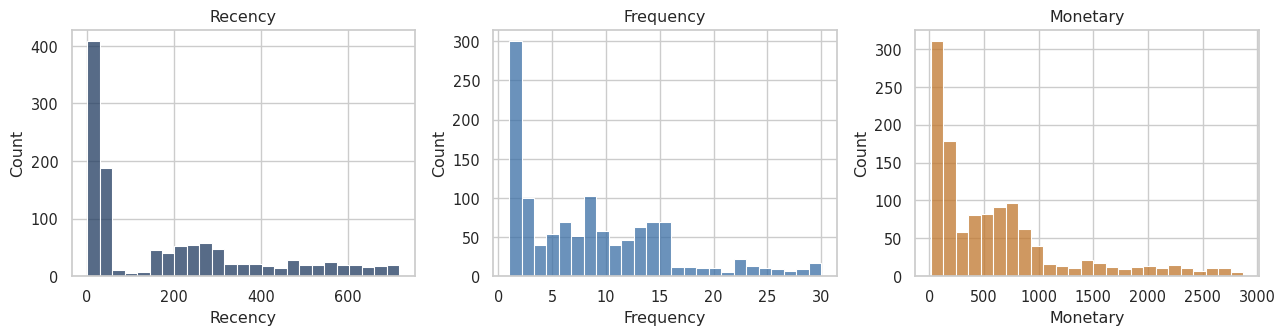

RFM summary statistics:
        Recency  Frequency  Monetary
mean     192.70       8.67    618.31
median    60.00       7.00    452.50
std      207.69       7.06    649.30


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col, color in zip(axes, ["Recency", "Frequency", "Monetary"], ["#1f3a5f", "#3a6ea5", "#c0762c"]):
    sns.histplot(rfm[col], bins=25, ax=ax, color=color)
    ax.set_title(col)
plt.tight_layout()
plt.show()

print("RFM summary statistics:")
print(rfm[["Recency", "Frequency", "Monetary"]].agg(["mean", "median", "std"]).round(2))

## 4. Rule-Based RFM Scoring

Each dimension is split into quartiles and scored 1 to 4, with 4 always
representing the most favourable outcome for the business: recent
purchases, frequent purchases, and high spend. The three scores are
combined into a segment label using standard RFM segment definitions.

In [5]:
# For Recency, a lower value is better, so the quartile labels are reversed
rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M_score"] = pd.qcut(rfm["Monetary"], 4, labels=[1, 2, 3, 4]).astype(int)
rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

def label_segment(row):
    if row["R_score"] >= 4 and row["F_score"] >= 4 and row["M_score"] >= 3:
        return "Champions"
    if row["F_score"] >= 3 and row["M_score"] >= 3:
        return "Loyal Customers"
    if row["R_score"] >= 3 and row["F_score"] <= 2:
        return "New / Low Frequency"
    if row["R_score"] <= 2 and row["F_score"] >= 3:
        return "At Risk"
    if row["R_score"] <= 2 and row["F_score"] <= 2:
        return "Hibernating"
    return "Needs Attention"

rfm["Segment"] = rfm.apply(label_segment, axis=1)

segment_summary = rfm.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
).round(2).sort_values("Customers", ascending=False)
segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
Loyal Customers,439,118.38,12.74,885.51
Hibernating,391,437.00,3.30,159.26
New / Low Frequency,209,22.85,2.54,146.45
Champions,138,10.86,20.32,"1,816.39"
Needs Attention,17,30.06,8.24,418.71
At Risk,6,270.17,7.17,429.17


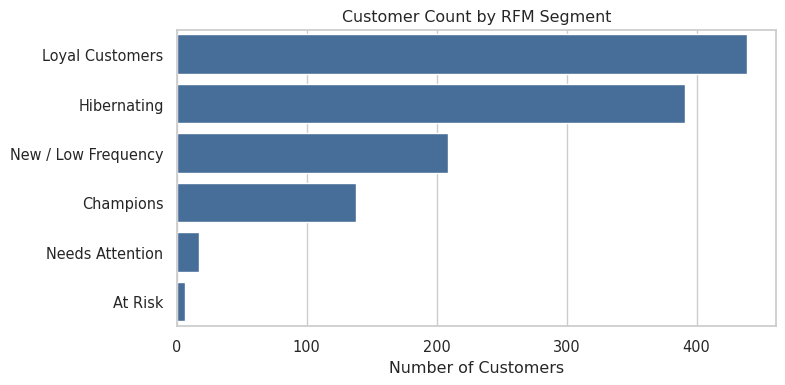

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
order = segment_summary.index
sns.barplot(x=segment_summary["Customers"], y=order, ax=ax, color="#3a6ea5")
ax.set_title("Customer Count by RFM Segment")
ax.set_xlabel("Number of Customers")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 5. Cluster Validation

An unsupervised check is applied to confirm the rule-based segments are
not an artefact of the scoring thresholds. RFM values are standardized and
clustered with k-means; the number of clusters is chosen using silhouette
score across a small candidate range.

In [7]:
scaler = StandardScaler()
X = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

sil_scores = {}
for k in range(2, 7):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    sil_scores[k] = round(silhouette_score(X, labels), 2)

best_k = max(sil_scores, key=sil_scores.get)
print("Silhouette score by number of clusters:", sil_scores)
print(f"Selected number of clusters: {best_k}")

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(X)

Silhouette score by number of clusters: {2: 0.43, 3: 0.49, 4: 0.51, 5: 0.49, 6: 0.49}
Selected number of clusters: 4


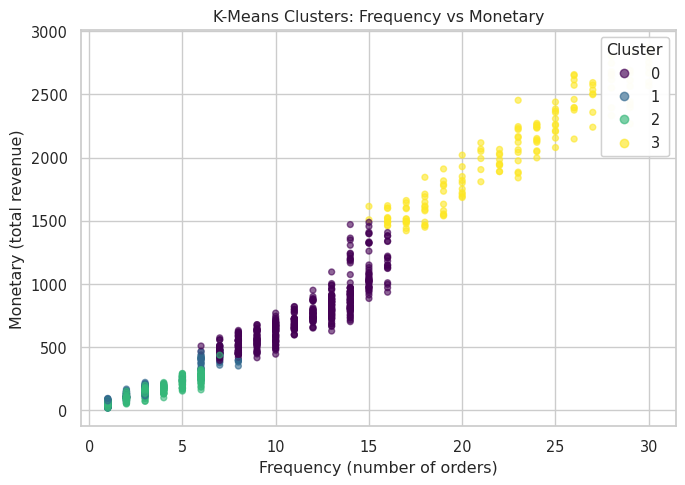

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    rfm["Frequency"], rfm["Monetary"], c=rfm["Cluster"], cmap="viridis", alpha=0.6, s=18
)
ax.set_xlabel("Frequency (number of orders)")
ax.set_ylabel("Monetary (total revenue)")
ax.set_title("K-Means Clusters: Frequency vs Monetary")
legend = ax.legend(*scatter.legend_elements(), title="Cluster", loc="upper right")
ax.add_artist(legend)
plt.tight_layout()
plt.show()

In [9]:
cross_tab = pd.crosstab(rfm["Segment"], rfm["Cluster"])
cross_tab

Cluster,0,1,2,3
Segment,,,,
At Risk,5,0,1,0
Champions,34,0,0,104
Hibernating,13,66,312,0
Loyal Customers,392,0,0,47
Needs Attention,11,6,0,0
New / Low Frequency,0,209,0,0


## 6. Findings and Recommendations

The revenue concentration in this analysis is pronounced: under half of
the customer base, Loyal Customers and Champions combined, generates more
than 86% of total revenue. Retention effort directed at these two
segments carries a disproportionate return relative to broad,
undifferentiated campaigns.

Three recommendations follow from the analysis:

1. Loyal Customers and Champions should be prioritised for a retention
   program, since losing customers in these segments would have an
   outsized revenue impact relative to their share of the customer count.
2. Hibernating customers, 32.58% of the base with an average recency of
   437.00 days, are unlikely to respond to standard win-back offers at
   that level of inactivity. A targeted reactivation campaign with a
   stronger incentive is more appropriate than routine marketing contact.
3. The close alignment between the rule-based segments and the k-means
   clusters, particularly for Loyal Customers and Hibernating, indicates
   the simpler rule-based approach is sufficient for ongoing operational
   use, with clustering reserved as a periodic validation check rather
   than the primary segmentation method.

## 7. Limitations

The dataset is synthetically generated from a fixed set of customer
archetypes, so the clean separation between segments seen here is
somewhat stronger than would typically be observed in real transaction
data, where customer behaviour is noisier and archetypes blend into one
another. The rule-based segment definitions also use fixed quartile
thresholds, which would need to be revisited periodically as the
underlying customer base changes.